# Task 3: Data Collection in the Wild - Human Activity Recognition (HAR)

This notebook demonstrates Task 3 of HAR, using custom data collected from a smartphone and applying a Decision Tree model trained on the UCI-HAR dataset. We will report accuracy, precision, recall, and confusion matrix, and optionally apply preprocessing and featurization.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(".."))
from tree.base import DecisionTree
from metrics import accuracy, precision, recall
sys.path.append(os.path.abspath(".\\Answer_HAR"))

In [2]:
## load custom dataset
def load_har_combined_data(base_dir):
    data = []
    for activity in os.listdir(base_dir):
        activity_dir = os.path.join(base_dir, activity)
        if not os.path.isdir(activity_dir):
            continue
        for csv_file in os.listdir(activity_dir):
            if not csv_file.endswith('.csv'):
                continue
            file_path = os.path.join(activity_dir, csv_file)
            arr = np.loadtxt(file_path, delimiter=',',comments='#', skiprows=4) 
            # Take a slice of the data to ensure uniform length from middle
            mid=len(arr)//2
            first=max(0,mid-500)
            last=min(len(arr),mid+500)
            arr = arr[first:last, : ]
            data.append({'time':arr[:,0],'acc_x': arr[:,1], 'acc_y': arr[:,2], 'acc_z': arr[:,3], 'activity': activity, 'subject': csv_file.replace('.csv','')})
    return pd.DataFrame(data)

In [3]:
df=load_har_combined_data(".\\Custom_ds")
df.head()

,time,acc_x,acc_y,acc_z,activity,subject
0,"[6.867571, 6.879924, 6.887901, 6.899246, 6.912...","[-0.0013, 0.0304, 0.0976, 0.0974, 0.0728, 0.03...","[0.088, 0.0432, 0.0012, -0.0392, -0.0936, -0.0...","[9.5791, 9.665, 9.7649, 9.8199, 9.8041, 9.7923...",LAYING,laying_1
1,"[7.874575, 7.887593, 7.894541, 7.9116, 7.92515...","[-0.0127, -0.0074, -0.0003, 0.0166, 0.0182, 0....","[0.0249, 0.0143, 0.0103, 0.0056, -0.0058, -0.0...","[9.63, 9.6181, 9.6221, 9.6491, 9.6611, 9.666, ...",LAYING,laying_2
2,"[13.583394, 13.598085, 13.603565, 13.614435, 1...","[-0.0151, -0.0171, -0.0288, 0.0005, -0.011, 0....","[-0.0269, -0.0134, 0.0129, 0.0212, 0.0345, 0.0...","[9.6486, 9.6107, 9.5987, 9.5936, 9.5776, 9.531...",LAYING,laying_3
3,"[6.719445, 6.72974, 6.748241, 6.749888, 6.7652...","[0.0061, 0.0009, -0.0132, 0.0173, 0.0031, -0.0...","[0.0018, -0.0075, -0.0323, -0.0006, 0.0166, 0....","[9.6729, 9.6578, 9.6608, 9.6817, 9.6917, 9.688...",LAYING,laying_4
4,"[8.524294, 8.544208, 8.544715, 8.56063, 8.5641...","[-0.0058, -0.0089, 0.0555, 0.0688, 0.0406, -0....","[-0.0296, -0.0125, 0.0027, 0.0233, 0.0156, -0....","[9.687, 9.632, 9.591, 9.548, 9.569, 9.605, 9.6...",LAYING,laying_5


In [4]:
## downsample df to 500 samples per row per axis time
def downsample_row(df, num_samples=500):
    for index, row in df.iterrows():
        time = row['time']
        acc_x = row['acc_x']
        acc_y = row['acc_y']
        acc_z = row['acc_z']
        
        if len(time) > num_samples:
            indices = np.linspace(0, len(time) - 1, num_samples).astype(int)
            df.at[index, 'time'] = time[indices]
            df.at[index, 'acc_x'] = acc_x[indices]
            df.at[index, 'acc_y'] = acc_y[indices]
            df.at[index, 'acc_z'] = acc_z[indices]
        elif len(time) < num_samples:
            padding_length = num_samples - len(time)
            df.at[index, 'time'] = np.pad(time, (0, padding_length), 'edge')
            df.at[index, 'acc_x'] = np.pad(acc_x, (0, padding_length), 'edge')
            df.at[index, 'acc_y'] = np.pad(acc_y, (0, padding_length), 'edge')
            df.at[index, 'acc_z'] = np.pad(acc_z, (0, padding_length), 'edge')
    return df
df = downsample_row(df, num_samples=500)
df['acc_x'][0].shape

(500,)

In [5]:
# Scale the accelerometer data to be in range -1 to 1 instead of -10 to 10
df[['acc_x', 'acc_y', 'acc_z']]=df[['acc_x', 'acc_y', 'acc_z']]/10

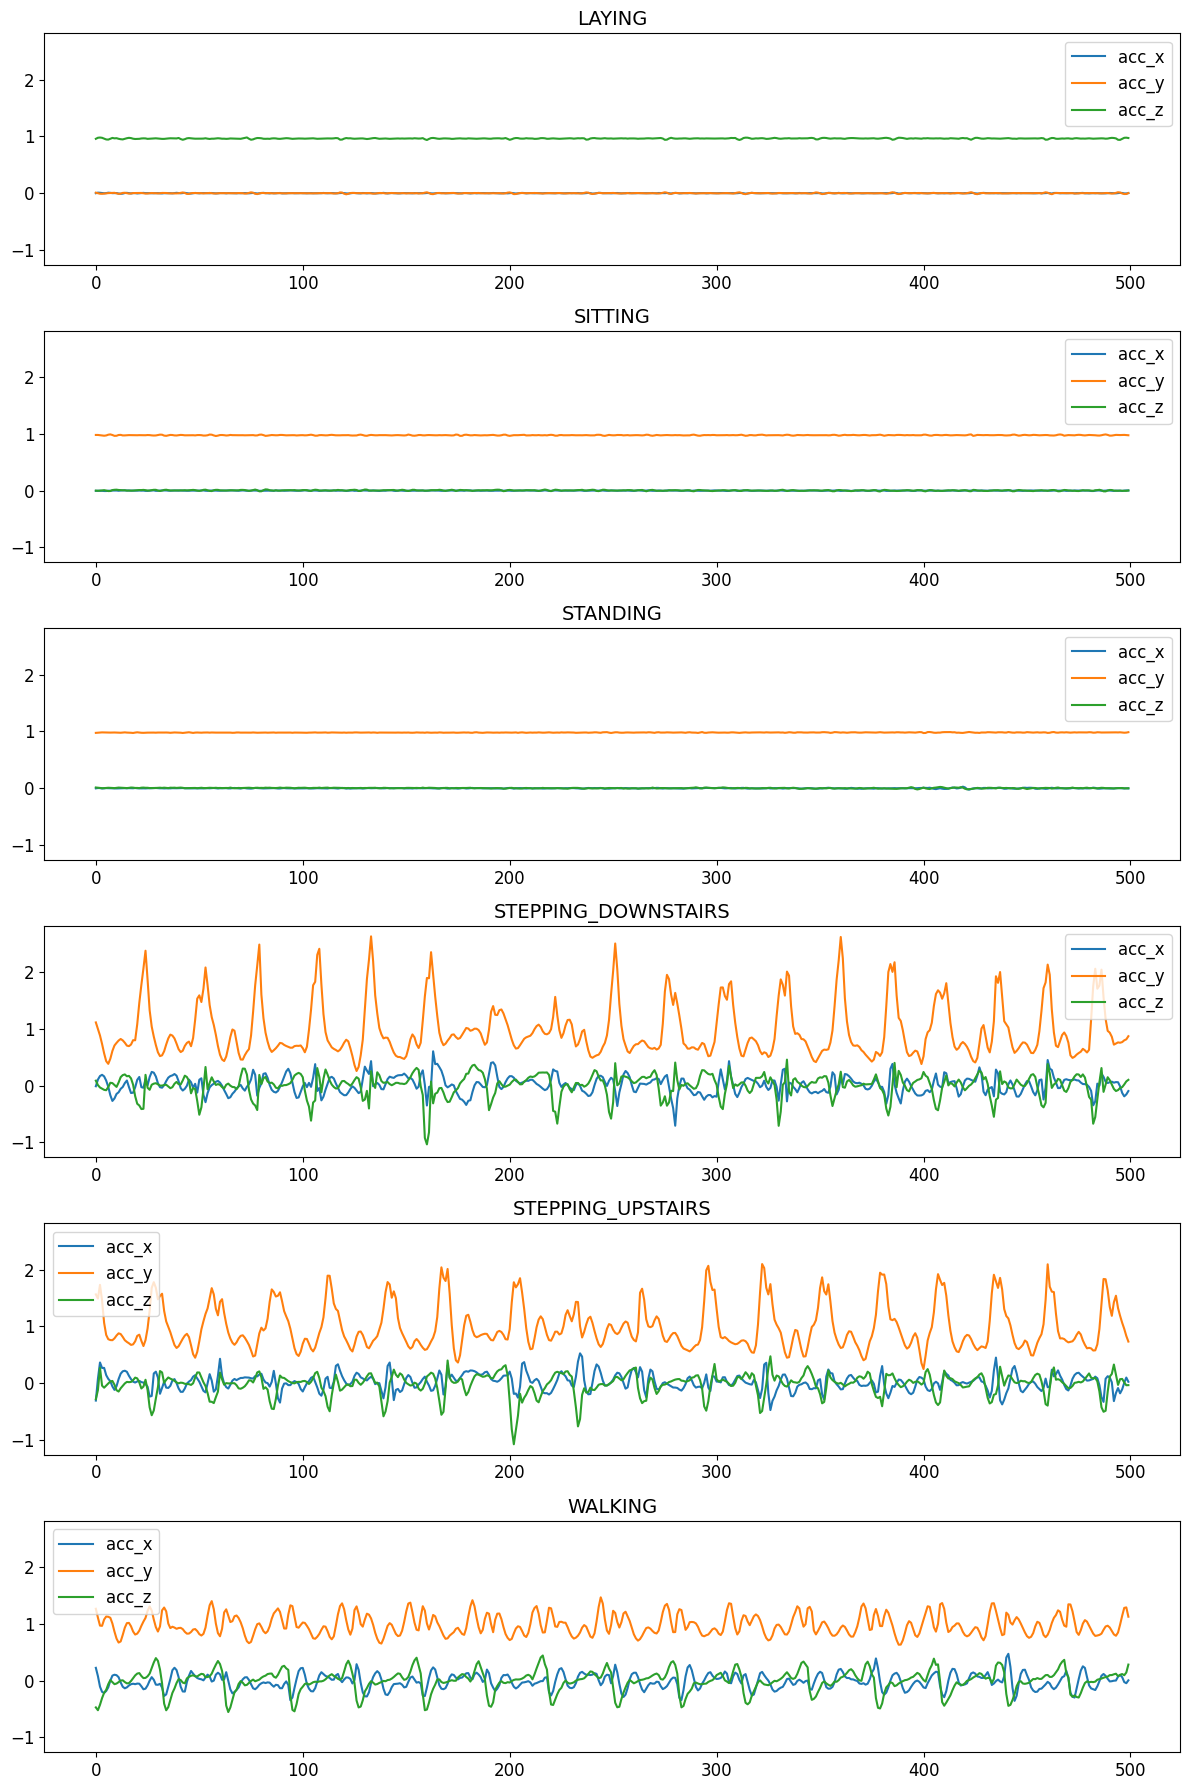

In [6]:
activity_classes = df['activity'].unique()
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 3 * len(activity_classes)), sharey=True)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    sample = df[df['activity'] == activity].iloc[0]
    acc_x = sample['acc_x']
    acc_y = sample['acc_y']
    acc_z = sample['acc_z']
    axes[i].plot(acc_x, label='acc_x')
    axes[i].plot(acc_y, label='acc_y')
    axes[i].plot(acc_z, label='acc_z')
    axes[i].set_title(activity, fontsize=14)
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Prepare total acceleration features 
X_total_acc = []
y_labels = []
for idx, row in df.iterrows():
    acc_x = row['acc_x']
    acc_y = row['acc_y']
    acc_z = row['acc_z']
    total_acc = (acc_x**2 + acc_y**2 + acc_z**2)**0.5
    X_total_acc.append(total_acc)
    y_labels.append(row['activity'])
X_total_acc = np.array(X_total_acc)
df['total_acc'] = list(X_total_acc)

In [8]:
df.head()

,time,acc_x,acc_y,acc_z,activity,subject,total_acc
0,"[6.867571, 6.887901, 6.91207, 6.929969, 6.9471...","[-0.00013, 0.009760000000000001, 0.00728, 0.00...","[0.008799999999999999, 0.00011999999999999999,...","[0.95791, 0.9764900000000001, 0.98041, 0.97566...",LAYING,laying_1,"[0.9579504293020595, 0.9765387816671697, 0.980..."
1,"[7.874575, 7.894541, 7.925152, 7.935901, 7.954...","[-0.0012699999999999999, -2.9999999999999997e-...","[0.00249, 0.00103, -0.00058, -0.00238, -0.0011...","[0.9630000000000001, 0.96221, 0.96610999999999...",LAYING,laying_2,"[0.9630040565854331, 0.9622105517504992, 0.966..."
2,"[13.583394, 13.603565, 13.630246, 13.648603, 1...","[-0.00151, -0.0028799999999999997, -0.00109999...","[-0.00269, 0.00129, 0.0034500000000000004, 0.0...","[0.96486, 0.9598699999999999, 0.95776000000000...",LAYING,laying_3,"[0.9648649313764078, 0.959875187407196, 0.9577..."
3,"[6.719445, 6.748241, 6.765234, 6.780773, 6.799...","[0.0006100000000000001, -0.00132, 0.00031, -0....","[0.00017999999999999998, -0.003230000000000000...","[0.96729, 0.96608, 0.9691700000000001, 0.96917...",LAYING,laying_4,"[0.9672902090892889, 0.9660863013727087, 0.969..."
4,"[8.524294, 8.544715, 8.564127, 8.59373, 8.6110...","[-0.00058, 0.00555, 0.004059999999999999, -0.0...","[-0.00296, 0.00027, 0.00156, -0.00465, 0.00108...","[0.9686999999999999, 0.9591, 0.956900000000000...",LAYING,laying_5,"[0.9687046959729264, 0.9591160958924628, 0.956..."


C:\Users\sun\AppData\Local\Temp\ipykernel_628\853069391.py:16: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_628\853069391.py:16: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_628\853069391.py:16: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_628\853069391.py:16: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_628\853069391.py:16: UserWarning: Using default sampling frequency set in configuration file.
  feat = tsfel.time_

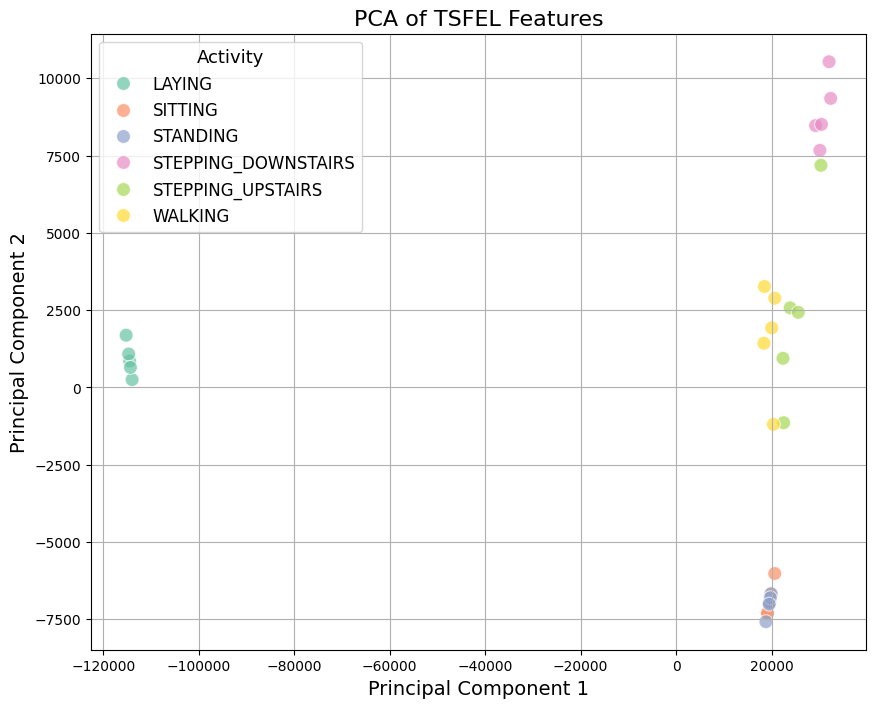

In [168]:

# Extract TSFEL features for each sample (using acc_x as example)
import tsfel
from sklearn.decomposition import PCA
cfg = tsfel.get_features_by_domain()


selected_domains = ['statistical', 'temporal']
cfg_selected = {k: v for k, v in cfg.items() if k in selected_domains}

ts_features = []

for sample in df[['acc_x', 'acc_y', 'acc_z']].values:
    feat_list = []
    for axis in range(3):
        ts = sample[axis]
        feat = tsfel.time_series_features_extractor(cfg_selected, ts, verbose=0)
        feat_list.append(feat.values.flatten())
    combined_features = np.hstack(feat_list)
    ts_features.append(combined_features)

# Apply PCA
pca = PCA(n_components=2)
ts_pca = pca.fit_transform(ts_features)

# Plot PCA results for four components
plt.figure(figsize=(10, 8))
sns.scatterplot(x=ts_pca[:, 0], y=ts_pca[:, 1], hue=y_labels, palette='Set2', s=100, alpha=0.7)
plt.title('PCA of TSFEL Features', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.legend(title='Activity', fontsize=12, title_fontsize=13)
plt.grid(True)
plt.show()

In [172]:
len(ts_features[0])

135

In [169]:
df["tsefl"]=list(ts_features)

In [170]:
df.head()

,time,acc_x,acc_y,acc_z,activity,subject,tsefl,total_acc
0,"[6.867571, 6.879924, 6.887901, 6.899246, 6.912...","[-0.0013, 0.0304, 0.0976, 0.0974, 0.0728, 0.03...","[0.088, 0.0432, 0.0012, -0.0392, -0.0936, -0.0...","[9.5791, 9.665, 9.7649, 9.8199, 9.8041, 9.7923...",LAYING,laying_1,"[0.68423748, 0.18049550000000003, 2.0, 0.06849...","[9.579504293020594, 9.665144354845404, 9.76538..."
1,"[7.874575, 7.887593, 7.894541, 7.9116, 7.92515...","[-0.0127, -0.0074, -0.0003, 0.0166, 0.0182, 0....","[0.0249, 0.0143, 0.0103, 0.0056, -0.0058, -0.0...","[9.63, 9.6181, 9.6221, 9.6491, 9.6611, 9.666, ...",LAYING,laying_2,"[0.58843621, 0.1763355000000001, 2.0, 0.058902...","[9.630040565854332, 9.618113477184599, 9.62210..."
2,"[13.583394, 13.598085, 13.603565, 13.614435, 1...","[-0.0151, -0.0171, -0.0288, 0.0005, -0.011, 0....","[-0.0269, -0.0134, 0.0129, 0.0212, 0.0345, 0.0...","[9.6486, 9.6107, 9.5987, 9.5936, 9.5776, 9.531...",LAYING,laying_3,"[0.5610624099999999, 0.17587499999999998, 2.0,...","[9.648649313764077, 9.610724554371538, 9.59875..."
3,"[6.719445, 6.72974, 6.748241, 6.749888, 6.7652...","[0.0061, 0.0009, -0.0132, 0.0173, 0.0031, -0.0...","[0.0018, -0.0075, -0.0323, -0.0006, 0.0166, 0....","[9.6729, 9.6578, 9.6608, 9.6817, 9.6917, 9.688...",LAYING,laying_4,"[0.6564994900000001, 0.18304499999999976, 2.0,...","[9.672902090892888, 9.65780295408847, 9.660863..."
4,"[8.524294, 8.544208, 8.544715, 8.56063, 8.5641...","[-0.0058, -0.0089, 0.0555, 0.0688, 0.0406, -0....","[-0.0296, -0.0125, 0.0027, 0.0233, 0.0156, -0....","[9.687, 9.632, 9.591, 9.548, 9.569, 9.605, 9.6...",LAYING,laying_5,"[0.5151616, 0.16274899999999995, 2.0, 0.051567...","[9.687046959729265, 9.632012222791248, 9.59116..."


### This is decision tree implementation from scratch's performance on our custom data.

In [48]:
## train decision tree classifier on tsfel features
X_train=[]
y_train=[]
X_test=[]
y_test=[]
activity_classes = df['activity'].unique()
for activity in activity_classes:
    df_activity = df[df['activity'] == activity]
    X_train.extend(df_activity['tsefl'].tolist()[:4])
    y_train.extend(df_activity['activity'].tolist()[:4])
    X_test.extend(df_activity['tsefl'].tolist()[4:])
    y_test.extend(df_activity['activity'].tolist()[4:])
dt=DecisionTree(criterion='gini_index',max_depth=4)
dt.fit(pd.DataFrame(X_train), pd.Series(y_train))


In [49]:
dt.plot()


Decision Tree with criterion: gini_index  and max_depth: 4 .

Root: ?(0 <= 473.70115661895) | IG: 0.1667 | Samples: 24
    ├── Y: Leaf | Value: LAYING | Samples: 4
    └── N: ?(0 <= 508.08188386790005) | IG: 0.2 | Samples: 20
        ├── Y: ?(88 <= 4.647149865929514e-07) | IG: 0.5 | Samples: 8
        |   ├── Y: Leaf | Value: STANDING | Samples: 4
        |   └── N: Leaf | Value: SITTING | Samples: 4
        └── N: ?(0 <= 597.20478029215) | IG: 0.3333 | Samples: 12
            ├── Y: ?(4 <= 4.997032571215303) | IG: 0.5 | Samples: 8
            |   ├── Y: Leaf | Value: WALKING | Samples: 4
            |   └── N: Leaf | Value: STEPPING_UPSTAIRS | Samples: 4
            └── N: Leaf | Value: STEPPING_DOWNSTAIRS | Samples: 4


In [14]:
dt.predict(pd.DataFrame(X_test))

0                 LAYING
1                SITTING
2               STANDING
3    STEPPING_DOWNSTAIRS
4                WALKING
5                WALKING
dtype: object

In [15]:
y_test=pd.Series(y_test)
print("Accuracy:", accuracy(y_test, dt.predict(pd.DataFrame(X_test))))


Accuracy: 0.8333333333333334


### Testing sklearn decision tree trained on UCI HAR dataset on our custom data

In [173]:
import joblib
tsfeltree = joblib.load('tsfeltree_model_all_axis.joblib')

In [ ]:
drop_columns=[  5,   6,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  55,
        70,  78,  80,  83,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,
        96,  97,  99, 100, 101, 102, 103, 104, 105, 112, 113, 114, 121, 155]
col=list([np.int64(3), np.int64(8), np.int64(23), np.int64(25), np.int64(28), np.int64(29), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(49), np.int64(52), np.int64(53), np.int64(54), np.int64(57), np.int64(58), np.int64(61), np.int64(64), np.int64(65), np.int64(67), np.int64(68), np.int64(71), np.int64(73), np.int64(74), np.int64(75), np.int64(77), np.int64(79), np.int64(81), np.int64(85), np.int64(115), np.int64(116), np.int64(117), np.int64(119), np.int64(120), np.int64(122), np.int64(123), np.int64(124), np.int64(125), np.int64(127), np.int64(128), np.int64(129), np.int64(130), np.int64(131), np.int64(132), np.int64(133), np.int64(134), np.int64(135), np.int64(137), np.int64(138), np.int64(139), np.int64(140), np.int64(141), np.int64(142), np.int64(143), np.int64(144), np.int64(145), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152), np.int64(153), np.int64(154)])
drop_columns.extend(col)

In [174]:
x_df = pd.DataFrame(ts_features)
# x_df.drop(columns=drop_columns, inplace=True)
x_df

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134
0,0.684237,0.180496,2.0,0.068492,4.651910,200.0,800.0,-0.0158,0.0217,0.001,...,0.4513,181.0,9.632571,999.671843,-1.036781,0.000029,0.066177,26.2368,0.004379,0.0
1,0.588436,0.176336,2.0,0.058903,4.611445,200.0,800.0,-0.0196,0.0203,0.001,...,0.3202,197.0,9.648324,999.541081,-0.461830,0.000028,0.052689,24.3166,0.002776,0.0
2,0.561062,0.175875,2.0,0.056162,4.891816,200.0,800.0,-0.0130,0.0265,0.001,...,0.3379,166.0,9.590959,999.526878,-0.047930,0.000021,0.059772,24.9869,0.003573,0.0
3,0.656499,0.183045,2.0,0.065716,4.420561,200.0,800.0,-0.0249,0.0152,0.001,...,0.3743,168.0,9.690185,999.516545,-0.269460,0.000013,0.058436,24.1780,0.003415,0.0
4,0.515162,0.162749,2.0,0.051568,4.643996,200.0,800.0,-0.0108,0.0238,0.001,...,0.4437,166.0,9.618476,999.510350,-0.333952,0.000027,0.060855,23.8385,0.003703,0.0
5,0.640736,0.191290,3.0,0.064138,4.791186,200.0,800.0,-0.0090,0.0303,0.001,...,0.4006,174.0,0.080709,999.608331,-0.146815,-0.000060,0.063953,26.6098,0.004090,124.0
6,0.548678,0.172940,3.0,0.054923,4.527308,200.0,800.0,-0.0111,0.0251,0.001,...,0.3187,167.0,0.058962,999.586573,0.235993,0.000011,0.058918,26.6383,0.003471,179.0
7,0.832298,0.217067,3.0,0.083313,4.814594,200.0,800.0,-0.0371,0.0043,0.001,...,0.2422,192.0,0.048241,999.364892,0.157049,-0.000010,0.041557,21.3478,0.001727,167.0
8,2.078917,0.331020,4.0,0.208100,3.653785,200.0,800.0,-0.0467,0.0071,0.001,...,0.3963,178.0,0.111769,999.546903,-0.149426,0.000021,0.059916,25.2316,0.003590,55.0
9,1.025093,0.240139,3.0,0.102612,5.003117,200.0,800.0,-0.0282,0.0271,0.001,...,0.2984,194.0,0.055387,999.492719,-0.087202,-0.000018,0.046530,23.6631,0.002165,161.0


In [175]:
tsfeltree.score(x_df,df['activity'])

0.16666666666666666

### We can see that the decision tree model trained on UCI HAR dataset performs poorly on our custom data, with an accuracy of only 16%. This suggests that the model may not generalize well to new data, as our new data is different in acceleration value for different activities compared from the UCI HAR dataset.